# Loan Default Risk - Exploratory Data Analysis

## Business Problem
The bank aims to reduce loan default rates by identifying borrower characteristics
associated with higher default risk and improving loan approval decisions.

The bank needs to balance two objectives:

- Expanding access to credit
- Controlling credit risk

This project uses Exploratory Data Analysis (EDA) to identify patterns associated
with loan default.

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Data

In [36]:
df = pd.read_csv("credit_risk_dataset.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


## 3. Dataset Overview

Inspect the structure, data types and basic statistics of the dataset

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [38]:
df.columns.tolist()

['person_age',
 'person_income',
 'person_home_ownership',
 'person_emp_length',
 'loan_intent',
 'loan_grade',
 'loan_amnt',
 'loan_int_rate',
 'loan_status',
 'loan_percent_income',
 'cb_person_default_on_file',
 'cb_person_cred_hist_length']

In [39]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


## 4. Data Quality

### 4.1. Missing Values

Check the number of missing values in each column

In [7]:
df.isnull().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

### 4.2. Missing Percentage

In [8]:
missing_pct = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

missing_pct

loan_int_rate                 9.563856
person_emp_length             2.747000
person_age                    0.000000
person_income                 0.000000
person_home_ownership         0.000000
loan_intent                   0.000000
loan_grade                    0.000000
loan_amnt                     0.000000
loan_status                   0.000000
loan_percent_income           0.000000
cb_person_default_on_file     0.000000
cb_person_cred_hist_length    0.000000
dtype: float64

### 4.3. Duplicates

Check and remove duplicate records.

In [9]:
print("Duplicates before:", df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 165
Duplicates after: 0


### 4.4. Check Unrealistic Values

In [40]:
print("Age <= 0:")
print(df[df['person_age'] <= 0])

print("\nIncome <= 0:")
print(df[df['person_income'] <= 0])

print("\nEmployment length < 0:")
print(df[df['person_emp_length'] < 0])

print("\nLoan amount <= 0:")
print(df[df['loan_amnt'] <= 0])

print("\nAge > 100 (unrealistically high):")
print(df[df['person_age'] > 100])

print("\nEmployment length > 60 (unrealistically high):")
print(df[df['person_emp_length'] > 60])

Age <= 0:
Empty DataFrame
Columns: [person_age, person_income, person_home_ownership, person_emp_length, loan_intent, loan_grade, loan_amnt, loan_int_rate, loan_status, loan_percent_income, cb_person_default_on_file, cb_person_cred_hist_length]
Index: []

Income <= 0:
Empty DataFrame
Columns: [person_age, person_income, person_home_ownership, person_emp_length, loan_intent, loan_grade, loan_amnt, loan_int_rate, loan_status, loan_percent_income, cb_person_default_on_file, cb_person_cred_hist_length]
Index: []

Employment length < 0:
Empty DataFrame
Columns: [person_age, person_income, person_home_ownership, person_emp_length, loan_intent, loan_grade, loan_amnt, loan_int_rate, loan_status, loan_percent_income, cb_person_default_on_file, cb_person_cred_hist_length]
Index: []

Loan amount <= 0:
Empty DataFrame
Columns: [person_age, person_income, person_home_ownership, person_emp_length, loan_intent, loan_grade, loan_amnt, loan_int_rate, loan_status, loan_percent_income, cb_person_default_

## 5. Handle Missing Values

Handle missing values using median imputation.

In [11]:
df['person_emp_length'] = (
    df['person_emp_length']
    .fillna(df['person_emp_length'].median())
)

df['loan_int_rate'] = (
    df['loan_int_rate']
    .fillna(df['loan_int_rate'].median())
)

In [12]:
df.isnull().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

## 6. Target Variable

The target variable is `loan_status`.

- `0` = Non-default
- `1` = Default

In [13]:
df['loan_status'].value_counts()

loan_status
0    25327
1     7089
Name: count, dtype: int64

In [14]:
df['loan_status'].value_counts(normalize=True)

loan_status
0    0.781312
1    0.218688
Name: proportion, dtype: float64

## 7. Overall Default Rate

Calculate the overall proportion of loans that resulted in default.

In [15]:
default_rate = df['loan_status'].mean()

print(f"Overall default rate: {default_rate:.2%}")

Overall default rate: 21.87%


## 8. Exploratory Data Analysis

### 8.1. Loan Default Distribution

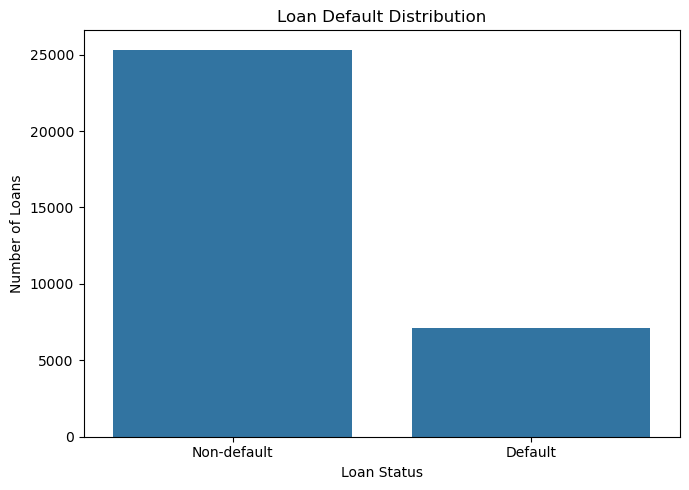

In [16]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x='loan_status'
)

ax.set_xticks([0, 1])
ax.set_xticklabels([
    'Non-default',
    'Default'
])

plt.title('Loan Default Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Number of Loans')

plt.tight_layout()
plt.show()

### 8.2. Income vs Loan Default

Compare income distributions between default and non-default borrowers.

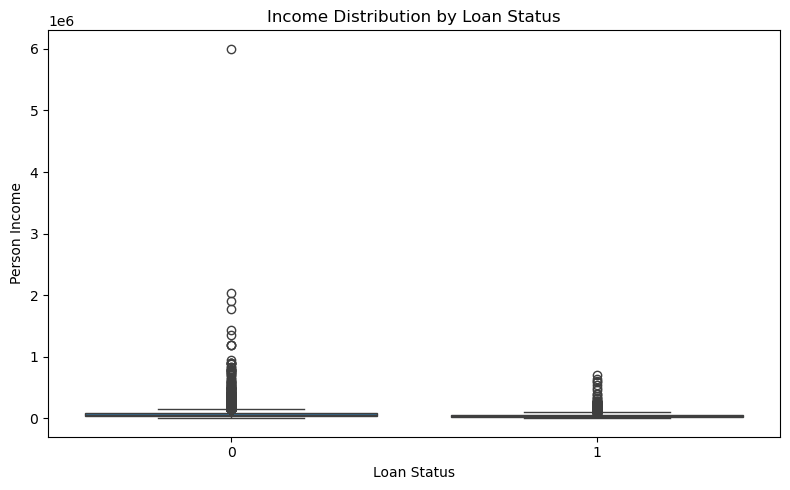

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='loan_status',
    y='person_income'
)

plt.title('Income Distribution by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('Person Income')

plt.tight_layout()
plt.show()

### 8.3. Age Distribution

Compare borrower age distributions between default and non-default groups.

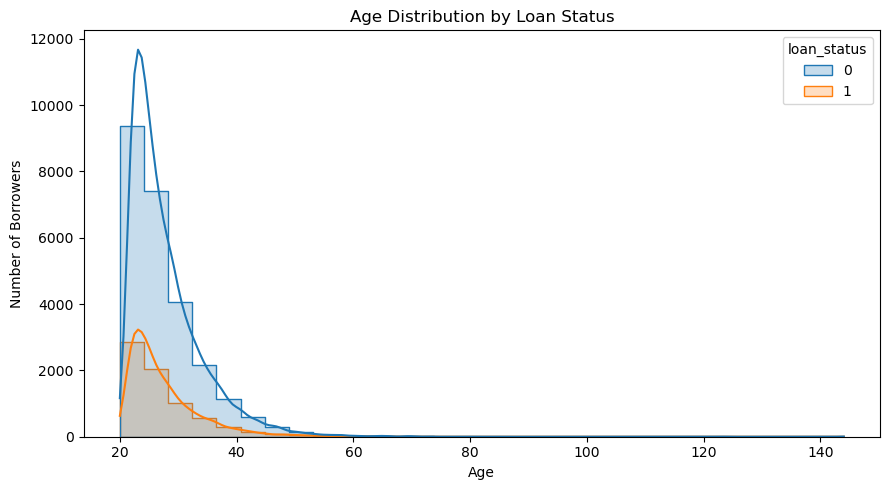

In [18]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='person_age',
    hue='loan_status',
    bins=30,
    kde=True,
    element='step'
)

plt.title('Age Distribution by Loan Status')
plt.xlabel('Age')
plt.ylabel('Number of Borrowers')

plt.tight_layout()
plt.show()

### 8.4. Loan Intent vs Default

Compare loan default patterns across different loan purposes.

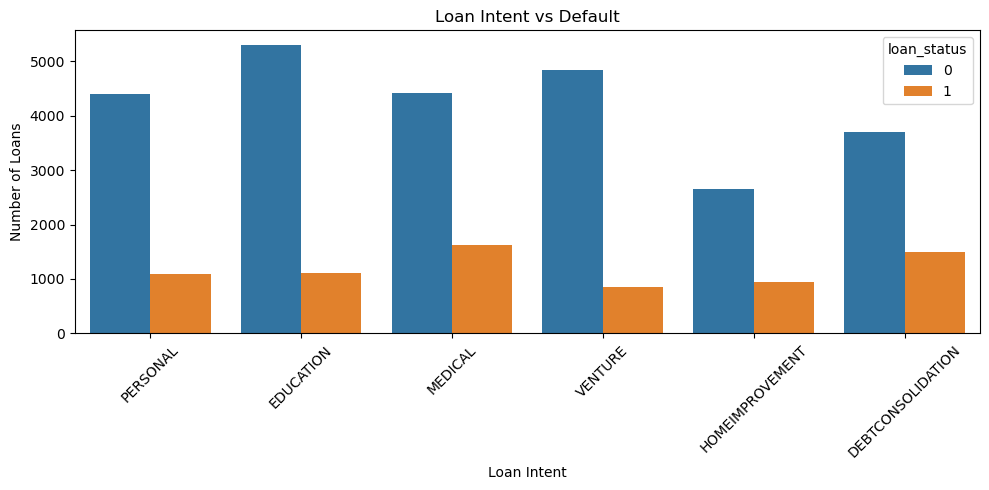

In [19]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x='loan_intent',
    hue='loan_status'
)

plt.title('Loan Intent vs Default')
plt.xlabel('Loan Intent')
plt.ylabel('Number of Loans')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 9. Default Rate by Loan Intent

In [20]:
intent_summary = (
    df.groupby('loan_intent')['loan_status']
      .agg(
          total_loans='size',
          defaults='sum',
          default_rate='mean'
      )
      .sort_values(
          'default_rate',
          ascending=False
      )
)

intent_summary['default_rate'] = (
    intent_summary['default_rate'] * 100
).round(2)

intent_summary

,total_loans,defaults,default_rate
loan_intent,,,
DEBTCONSOLIDATION,5189,1488,28.68
MEDICAL,6042,1617,26.76
HOMEIMPROVEMENT,3594,940,26.15
PERSONAL,5498,1094,19.90
EDUCATION,6411,1106,17.25
VENTURE,5682,844,14.85


## 10. Previous Default History

Analyze loan default patterns based on previous default history.

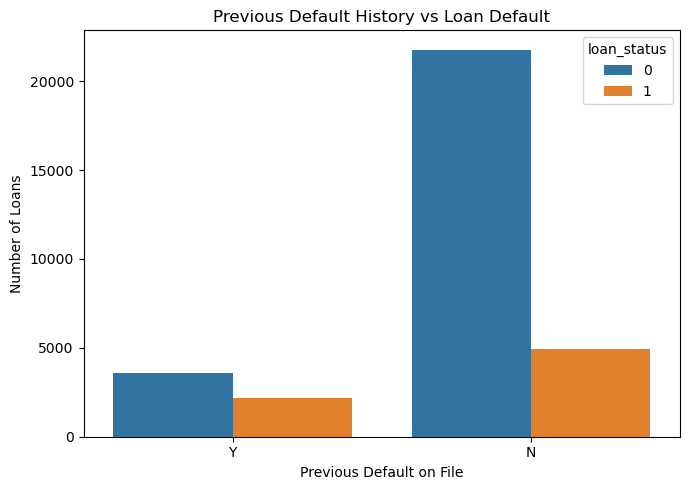

In [21]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x='cb_person_default_on_file',
    hue='loan_status'
)

plt.title('Previous Default History vs Loan Default')
plt.xlabel('Previous Default on File')
plt.ylabel('Number of Loans')

plt.tight_layout()
plt.show()

## 11. Default Rate by Previous Default

In [22]:
prev_default_summary = (
    df.groupby(
        'cb_person_default_on_file'
    )['loan_status']
    .agg(
        total_loans='size',
        defaults='sum',
        default_rate='mean'
    )
)

prev_default_summary['default_rate'] = (
    prev_default_summary['default_rate'] * 100
).round(2)

prev_default_summary

,total_loans,defaults,default_rate
cb_person_default_on_file,,,
N,26686,4919,18.43
Y,5730,2170,37.87


## 12. Feature Engineering - LTI

Create Loan-to-Income Ratio (LTI).

LTI = Loan Amount / Person Income

In [23]:
df['LTI'] = (
    df['loan_amnt'] /
    df['person_income']
)

df[['loan_amnt', 'person_income', 'LTI']].head()

,loan_amnt,person_income,LTI
0,35000,59000,0.593220
1,1000,9600,0.104167
2,5500,9600,0.572917
3,35000,65500,0.534351
4,35000,54400,0.643382


## 13. LTI Distribution

Explore the distribution of Loan-to-Income Ratio.

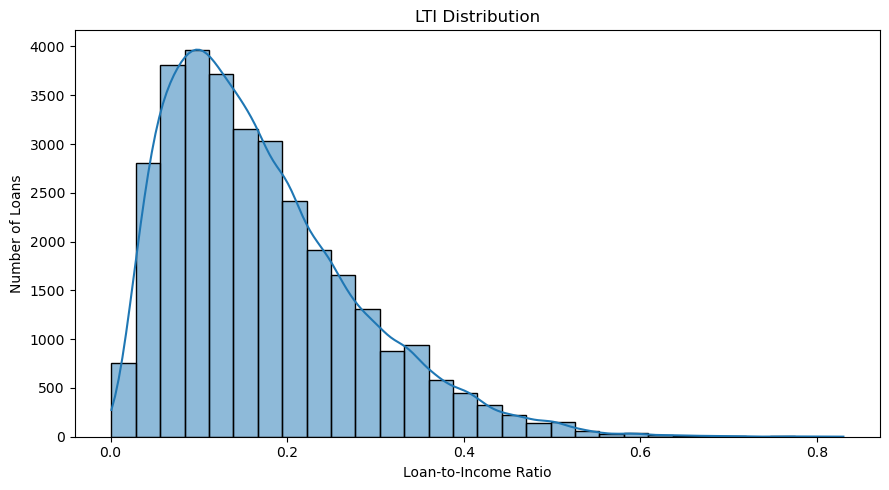

In [24]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='LTI',
    bins=30,
    kde=True
)

plt.title('LTI Distribution')
plt.xlabel('Loan-to-Income Ratio')
plt.ylabel('Number of Loans')

plt.tight_layout()
plt.show()

## 14. LTI vs Loan Default

Compare LTI distributions between default and non-default borrowers.

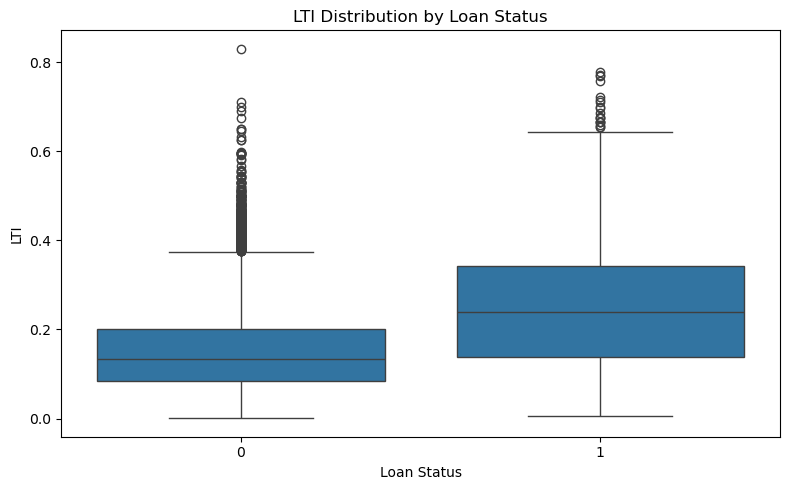

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x='loan_status',
    y='LTI'
)

plt.title('LTI Distribution by Loan Status')
plt.xlabel('Loan Status')
plt.ylabel('LTI')

plt.tight_layout()
plt.show()

## 15. LTI vs loan_percent_income

Measure the linear correlation between LTI and loan_percent_income.

In [26]:
corr_lti = (
    df[['LTI', 'loan_percent_income']]
      .corr()
      .iloc[0, 1]
)

print(
    f"Correlation LTI vs loan_percent_income: "
    f"{corr_lti:.5f}"
)

Correlation LTI vs loan_percent_income: 0.99894


## 16. LTI Grouping

LTI Group are analytical buckets created to make it easier to compare default rates across ranges of LTI. They are grouping bins for analysis, not formal credit-risk thresholds.

In [27]:
bins = [
    0,
    0.10,
    0.20,
    0.30,
    0.40,
    float('inf')
]

labels = [
    '<10%',
    '10-20%',
    '20-30%',
    '30-40%',
    '40%+'
]

df['LTI_Group'] = pd.cut(
    df['LTI'],
    bins=bins,
    labels=labels,
    right=False
)

df[['LTI', 'LTI_Group']].head()

,LTI,LTI_Group
0,0.593220,40%+
1,0.104167,10-20%
2,0.572917,40%+
3,0.534351,40%+
4,0.643382,40%+


## 17. Default Rate by LTI Group

In [28]:
lti_summary = (
    df.groupby(
        'LTI_Group',
        observed=True
    )['loan_status']
    .agg(
        total_loans='size',
        defaults='sum',
        default_rate='mean'
    )
)

lti_summary['default_rate'] = (
    lti_summary['default_rate'] * 100
).round(2)

lti_summary

,total_loans,defaults,default_rate
LTI_Group,,,
<10%,9429,1089,11.55
10-20%,12150,1774,14.60
20-30%,6698,1435,21.42
30-40%,2836,1820,64.17
40%+,1303,971,74.52


## 18. Chart - Default Rate by LTI Group

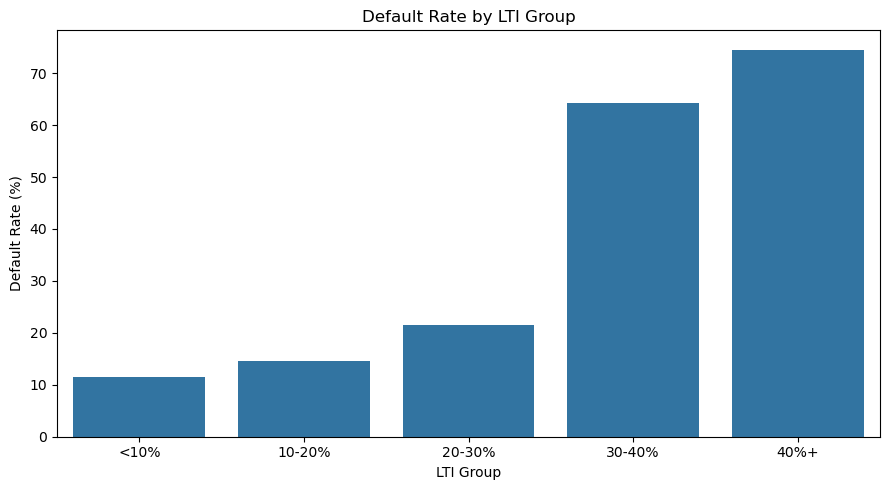

In [29]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=lti_summary.reset_index(),
    x='LTI_Group',
    y='default_rate'
)

plt.title('Default Rate by LTI Group')
plt.xlabel('LTI Group')
plt.ylabel('Default Rate (%)')

plt.tight_layout()
plt.show()

## 19. Loan Intent × LTI Group

Analyze default rates across both loan intent and LTI groups.

In [30]:
lti_intent_rate = pd.pivot_table(
    df,
    index='loan_intent',
    columns='LTI_Group',
    values='loan_status',
    aggfunc='mean',
    observed=True
)

lti_intent_rate

LTI_Group,<10%,10-20%,20-30%,30-40%,40%+
loan_intent,,,,,
DEBTCONSOLIDATION,0.170143,0.208486,0.285850,0.738494,0.813953
EDUCATION,0.080472,0.110414,0.153214,0.554806,0.702222
HOMEIMPROVEMENT,0.162936,0.206948,0.314483,0.588462,0.697842
MEDICAL,0.145920,0.180717,0.252315,0.730298,0.845865
PERSONAL,0.104375,0.119297,0.195940,0.655405,0.751152
VENTURE,0.051376,0.082293,0.131830,0.565306,0.634855


## 20. Heatmap

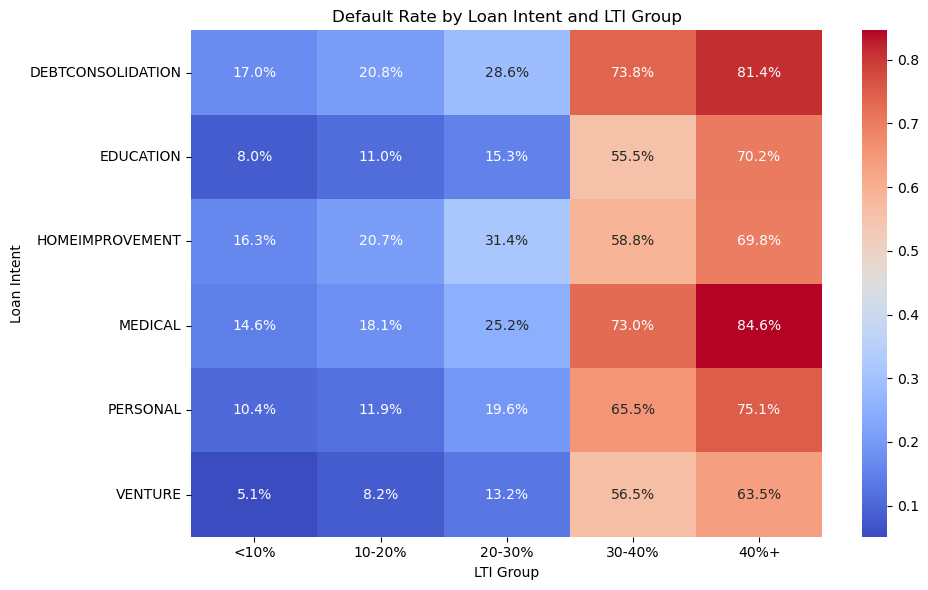

In [31]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    lti_intent_rate,
    annot=True,
    fmt='.1%',
    cmap='coolwarm'
)

plt.title(
    'Default Rate by Loan Intent and LTI Group'
)

plt.xlabel('LTI Group')
plt.ylabel('Loan Intent')

plt.tight_layout()
plt.show()

## 21. Correlation Analysis

Analyze linear correlations between numerical variables.

In [32]:
numeric_cols = df.select_dtypes(
    include=np.number
)

corr_matrix = numeric_cols.corr()

corr_matrix

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,LTI
person_age,1.000000,0.173293,0.161342,0.050680,0.011074,-0.022698,-0.042300,0.859215,-0.042166
person_income,0.173293,1.000000,0.134791,0.265947,0.000826,-0.145005,-0.254472,0.117614,-0.253188
person_emp_length,0.161342,0.134791,1.000000,0.113934,-0.051462,-0.082517,-0.054024,0.143251,-0.052792
loan_amnt,0.050680,0.265947,0.113934,1.000000,0.139596,0.105736,0.572824,0.041865,0.577228
loan_int_rate,0.011074,0.000826,-0.051462,0.139596,1.000000,0.320081,0.114411,0.015000,0.118893
loan_status,-0.022698,-0.145005,-0.082517,0.105736,0.320081,1.000000,0.379697,-0.016498,0.386218
loan_percent_income,-0.042300,-0.254472,-0.054024,0.572824,0.114411,0.379697,1.000000,-0.031457,0.998939
cb_person_cred_hist_length,0.859215,0.117614,0.143251,0.041865,0.015000,-0.016498,-0.031457,1.000000,-0.031425
LTI,-0.042166,-0.253188,-0.052792,0.577228,0.118893,0.386218,0.998939,-0.031425,1.000000


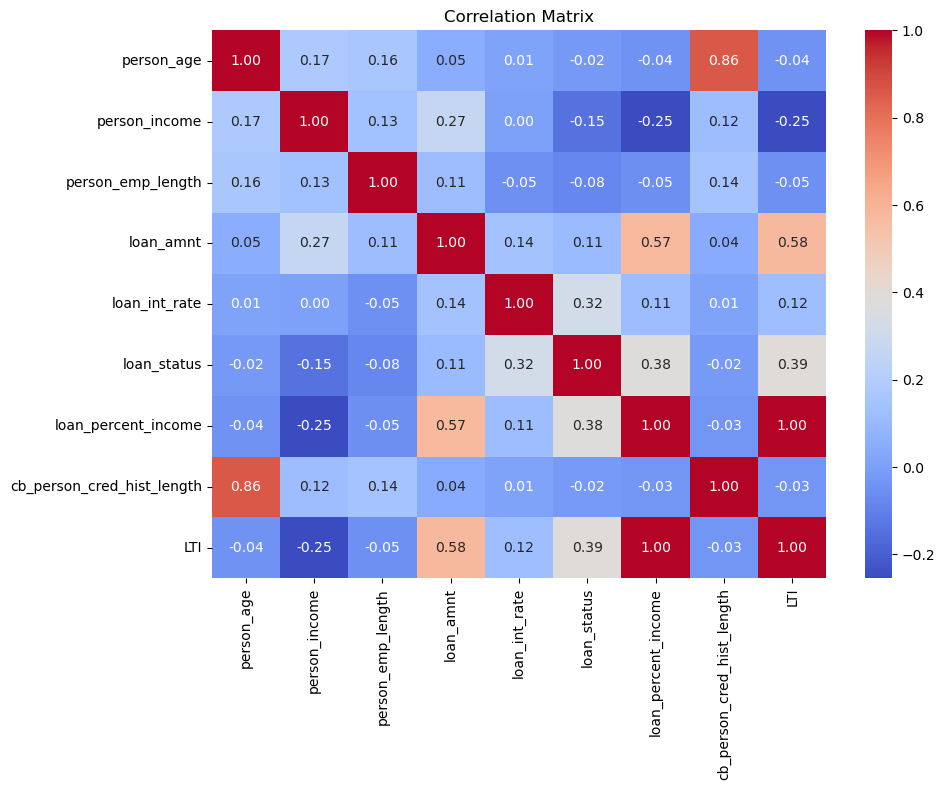

In [33]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.tight_layout()
plt.show()

## 22. Additional EDA Charts

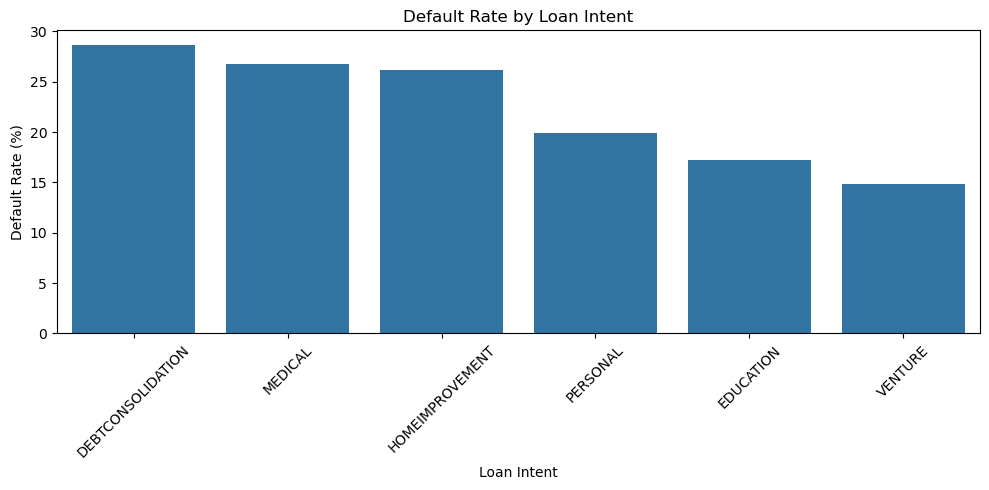

In [34]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=intent_summary.reset_index(),
    x='loan_intent',
    y='default_rate'
)

plt.title('Default Rate by Loan Intent')
plt.xlabel('Loan Intent')
plt.ylabel('Default Rate (%)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

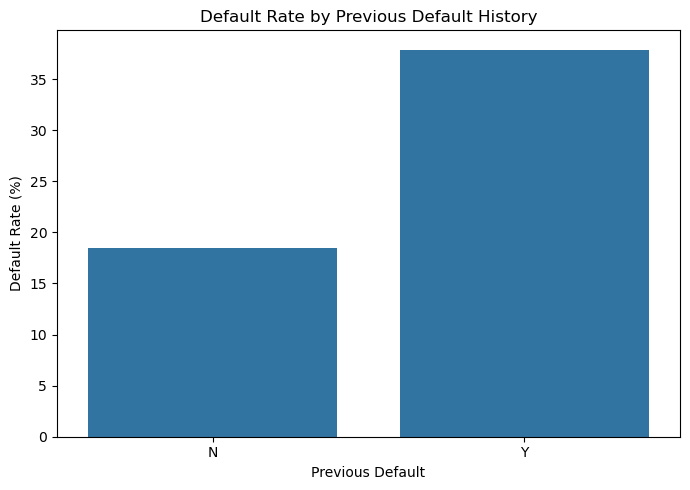

In [35]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=prev_default_summary.reset_index(),
    x='cb_person_default_on_file',
    y='default_rate'
)

plt.title('Default Rate by Previous Default History')
plt.xlabel('Previous Default')
plt.ylabel('Default Rate (%)')

plt.tight_layout()
plt.show()

## 23. Key Findings

### 1. Overall Default Rate

The overall default rate is **21.87%**.

### 2. Loan Intent

Default rates vary across loan intent groups:

- **DEBTCONSOLIDATION:** 28.68%
- **MEDICAL:** 26.76%
- **HOMEIMPROVEMENT:** 26.15%
- **VENTURE:** 14.85%

### 3. Previous Default History

Borrowers with a previous default (**Y**) have a default rate of **37.87%**, compared with **18.43%** for borrowers without a previous default (**N**).

### 4. LTI

Default rates increase as LTI increases, from **11.55%** for the **<10%** group to **74.52%** for the **40%+** group.

### 5. LTI and loan_percent_income

LTI and loan_percent_income have a very strong linear correlation of approximately **0.999**.

### 6. Cross-analysis

Default rates vary across both Loan Intent and LTI Group. The highest observed rate is **84.6%** for **MEDICAL** loans in the **40%+** LTI group, while the lowest is **5.1%** for **VENTURE** loans in the **<10%** LTI group.

## 24. Potential Business Applications

The observed patterns could be used to support further credit-risk analysis.

Potential applications include:

- Using LTI as a candidate feature for future credit-risk modeling.
- Further investigating borrowers with previous default history.
- Monitoring differences in default rates across loan intents.
- Using LTI and borrower characteristics as inputs for future predictive modeling.

## 25. Limitations

- This analysis focuses on exploratory relationships rather than causal inference.
- LTI groups are analytical buckets, not formal credit-risk thresholds.
- Some variables contain missing values that require appropriate treatment.
- Extreme values should be reviewed based on business context rather than removed solely using statistical rules.
- The analysis does not evaluate predictive model performance.
- The findings describe patterns within this dataset and may not generalize to other populations or lending environments.

## 26. Conclusion

This project used Python, Pandas, NumPy, Matplotlib, and Seaborn
to explore patterns associated with loan default risk.

The analysis examined:

- Overall default rate
- Loan intent
- Previous default history
- Borrower income
- Loan-to-Income Ratio (LTI)
- LTI groups
- Loan Intent × LTI Group
- Correlations between numerical variables

The analysis provides exploratory insights into observed
credit-risk patterns and can be used to form hypotheses for
further analysis.

These findings describe associations in the dataset and should
not be interpreted as causal effects or formal credit-risk
thresholds.